In [1]:
# Splice class labels
SPLICE_CLASS_NAMES = ["Donor+", "Acceptor+", "Donor-", "Acceptor-"]
BACKGROUND_CLASS = 4
ORGANISM_NAMES = {0: "human", 1: "mouse"}

CLASS_LABELS = {0: 'donor +', 1: 'acceptor +', 2: 'donor -', 3: 'acceptor -', 4: 'no splice site'}
CLASS_COLORS  = {0: '#ff7f00', 1: '#33a02c', 2: '#fdbf6f', 3: '#b2df8a', 4: '#1f78b4'}


In [2]:
import pandas as pd

genome="/home/elek/sds/sd17d003/Anamaria/genomes/mazin/fasta/Homo_sapiens.fa"
coords = "1:10000-30000"
coords = "1:38143127-38178460"

# Extract coordinates
if ":" in coords and "-" in coords:
    chrom, rest = coords.split(":", 1)
    start, end = rest.split("-")
elif ":" in coords:
    chrom, start, end = coords.split(":")
else:
    raise ValueError("Coordinates must be in 'chrom:start-end' or 'chrom:start:end' format")
start, end = int(start), int(end)

# We need chr lengtsh from fasta.fai
chr_lens = pd.read_csv(genome+".fai", sep='\t', header=None, usecols=[0, 1], names=['chrom', 'size'])
chr_len = int(chr_lens[chr_lens['chrom'] == chrom]['size'].values[0])

# Extract window centered on the region
seq_len = 131072
half = seq_len // 2
region_center = (start + end) // 2
win_start = max(region_center - half, 0)
if win_start == 0:
    win_end = min(seq_len, chr_len)
else:
    win_end = min(region_center + half, chr_len)
print(f"Predict for sequence {chrom}:{win_start}-{win_end}")

Predict for sequence 1:38095257-38226329


In [3]:
# Load genome sequence
try:
    import pyfaidx
    fasta = pyfaidx.Fasta(genome, as_raw=True, sequence_always_upper=True)
except ImportError:
    raise ImportError("pyfaidx required: pip install pyfaidx")

seq_str = str(fasta[chrom][win_start:win_end])
seq_str

'...'

In [4]:
# One-hot encode sequence
import numpy as np
import torch
from alphagenome_pytorch.utils.sequence import sequence_to_onehot
device="cuda"
organism=0
seq_np = sequence_to_onehot(seq_str).astype(np.float32)  # (S, 4)
if seq_np.shape[0] != seq_len:
    # Pad with zeros if sequence is too short (e.g. near chromosome ends)
    pad_len = seq_len - seq_np.shape[0]
    seq_np = np.pad(seq_np, ((0, pad_len), (0, 0)), mode="constant")
seq_t = torch.from_numpy(seq_np).unsqueeze(0).to(device)  # (1, S, 4)
org_t = torch.full((1,), organism, dtype=torch.long, device=device)

In [5]:
# Load model (pretrained or fine-tuned)

from alphagenome_pytorch.utils.model_loading import load_model_for_inference

# pretrained model
checkpoint="/home/elek/projects/alphagenome_ft_pytorch/checkpoints/model_fold_0.safetensors"

# fine-tuned model
#checkpoint="/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_linear/best_model.pth"
#checkpoint="/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_lora/best_model.pth"
#checkpoint="/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/524kb_lora/best_model.pth"

model, cfg = load_model_for_inference(checkpoint, device, strict=False)

model.eval()

AlphaGenome(
  (encoder): SequenceEncoder(
    (dna_embedder): DnaEmbedder(
      (conv1): Conv1d(4, 768, kernel_size=(15,), stride=(1,), padding=same)
      (block): ConvBlock(
        (norm): RMSBatchNorm()
        (conv): StandardizedConv1d(768, 768, kernel_size=(5,), stride=(1,))
      )
    )
    (pool): Pool1d()
    (down_blocks): ModuleList(
      (0): DownResBlock(
        (block1): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(768, 896, kernel_size=(5,), stride=(1,))
        )
        (block2): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(896, 896, kernel_size=(5,), stride=(1,))
        )
      )
      (1): DownResBlock(
        (block1): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(896, 1024, kernel_size=(5,), stride=(1,))
        )
        (block2): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(1024, 1024, kernel_size=(5,), stride=(1,)

In [6]:
# Predict splice site classification
with torch.no_grad():
    out = model.predict(seq_t, org_t, resolutions=(1,))
    probs = out["splice_sites_classification"]["probs"][0].cpu().numpy()  # (S, 5)

In [7]:
# Do probabilities sum to 1 per position?
per_pos_prob = probs.sum(axis=1)

# Range of summed probabilities should be very close to 1
print(f"Per-position probability sums: min={per_pos_prob.min():.4f}, max={per_pos_prob.max():.4f}")

Per-position probability sums: min=1.0000, max=1.0000


In [8]:
# Predicted classes across positions
pred_classes = np.argmax(probs, axis=-1)  # (S,)

# Count predicted classes
unique, counts = np.unique(pred_classes, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"Class {cls}: {cnt} positions")
    if cls != 4:  # If not "no splice site" print which positions are predicted as this class
        cls_probs = probs[:, cls]  # (S,)
        predicted_positions = np.where(pred_classes == cls)[0]  # Threshold at 0.2 for example
        print(f"  Predicted positions for class {cls}: {predicted_positions}")
        # Reconstruct genomic coordinates of predicted splice sites
        genomic_positions = predicted_positions + win_start  # Convert to genomic coordinates
        print(f"  Genomic coordinates for class {cls}: {genomic_positions}")

Class 0: 11 positions
  Predicted positions for class 0: [62992 63198 63447 66364 69391 70912 70935 72232 73761 75981 77478]
  Genomic coordinates for class 0: [38158249 38158455 38158704 38161621 38164648 38166169 38166192 38167489
 38169018 38171238 38172735]
Class 1: 12 positions
  Predicted positions for class 1: [ 63090  63319  66324  69319  70850  72168  73666  74534  75855  77392
  78736 124417]
  Genomic coordinates for class 1: [38158347 38158576 38161581 38164576 38166107 38167425 38168923 38169791
 38171112 38172649 38173993 38219674]
Class 2: 39 positions
  Predicted positions for class 2: [  2701   4980  53459  53733  56687  60020  60416  60630  60748  61873
  82022  84294  85145  86269  88790  88792  89056  89075  89367  89575
  89828  89922  90323  90765  91197  92074  93219  93455  93725  94206
  97516 101825 102773 103070 104478 104994 105671 123290 124629]
  Genomic coordinates for class 2: [38097958 38100237 38148716 38148990 38151944 38155277 38155673 38155887
 3815

In [9]:
# Load splice site parquet annotation for the region
import pandas as pd
fn="/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/Homo_sapiens/splice_sites_intersect.parquet"
pq = pd.read_parquet(fn)

fn="/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/Homo_sapiens/usage.parquet"
usage_pq = pd.read_parquet(fn)

fn = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/Homo_sapiens/splice_sites_gtf.parquet"
gtf_pq = pd.read_parquet(fn)

# Get true labels for the window we calculated predictions for
true_pq = pq[(pq['Chromosome'] == chrom) & (pq['Position'] >= win_start) & (pq['Position'] < win_end)]

# window coordinate
true_pq['WindowPosition'] = true_pq['Position'] - win_start

# Placeholder for background class
true_classes = np.full_like(pred_classes, fill_value=BACKGROUND_CLASS)

# Match SiteType to index in SPLICE_CLASS_NAMES
true_pq['TrueClass'] = true_pq['SiteType'].map({name: i for i, name in enumerate(SPLICE_CLASS_NAMES)})

# Fill placeholder with actual positive classes from parquet
true_classes[true_pq['WindowPosition'].values] = true_pq['TrueClass'].values

# Count true classes
unique, counts = np.unique(true_classes, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"Class {cls}: {cnt} positions")
    if cls != 4:  # If not "no splice site" print which positions are predicted as this class
        true_positions = np.where(true_classes == cls)[0]
        print(f"  True positions for class {cls} (n={len(true_positions)}):\n{true_positions}")
        # Reconstruct genomic coordinates of predicted splice sites
        genomic_positions = true_positions + win_start  # Convert to genomic coordinates
        print(f"  Genomic coordinates for class {cls} (n={len(genomic_positions)}):\n{genomic_positions}")

Class 0: 8 positions
  True positions for class 0 (n=8):
[63198 63447 66364 69391 70935 72232 73761 77478]
  Genomic coordinates for class 0 (n=8):
[38158455 38158704 38161621 38164648 38166192 38167489 38169018 38172735]
Class 1: 8 positions
  True positions for class 1 (n=8):
[63319 66324 69319 70850 72168 73666 75855 78736]
  Genomic coordinates for class 1 (n=8):
[38158576 38161581 38164576 38166107 38167425 38168923 38171112 38173993]
Class 2: 5 positions
  True positions for class 2 (n=5):
[ 53733  85145  93725  97516 105671]
  Genomic coordinates for class 2 (n=5):
[38148990 38180402 38188982 38192773 38200928]
Class 3: 6 positions
  True positions for class 3 (n=6):
[ 53574  84437  89230  93580  93786 101996]
  Genomic coordinates for class 3 (n=6):
[38148831 38179694 38184487 38188837 38189043 38197253]
Class 4: 131045 positions


In [10]:
# Calculate AUPR for each class (except background)
from sklearn.metrics import average_precision_score
for cls in range(4):
    true_labels = (true_classes == cls).astype(int)  # Binary labels for this class
    cls_probs = probs[:, cls]  # Predicted probabilities for this class
    aupr = average_precision_score(true_labels, cls_probs)
    print(f"AUPRC for class {cls} ({CLASS_LABELS[cls]}): {aupr:.4f}")

AUPRC for class 0 (donor +): 1.0000
AUPRC for class 1 (acceptor +): 0.9526
AUPRC for class 2 (donor -): 0.5004
AUPRC for class 3 (acceptor -): 0.4846


In [11]:
# Combined dataframe with positions where true or predicted class is not background
pred_non_bg = pred_classes != BACKGROUND_CLASS
true_non_bg = true_classes != BACKGROUND_CLASS
non_bg_positions = np.where(pred_non_bg | true_non_bg)[0]
results_df = pd.DataFrame({
    "Window_position": non_bg_positions,
    "Genomic_position": non_bg_positions + win_start,
    "Predicted_class": pred_classes[non_bg_positions],
    "True_class": true_classes[non_bg_positions],
    "Donor+_prob": probs[non_bg_positions, 0],
    "Acceptor+_prob": probs[non_bg_positions, 1],
    "Donor-_prob": probs[non_bg_positions, 2],
    "Acceptor-_prob": probs[non_bg_positions, 3],
    "Background_prob": probs[non_bg_positions, 4],
})

results_df

,Window_position,Genomic_position,Predicted_class,True_class,Donor+_prob,Acceptor+_prob,Donor-_prob,Acceptor-_prob,Background_prob
0,363,38095620,3,4,2.385492e-07,1.261836e-05,0.000078,0.980639,0.019270
1,2701,38097958,2,4,4.253460e-06,1.409145e-06,0.972299,0.000116,0.027579
2,2767,38098024,3,4,3.794794e-06,1.619964e-05,0.000192,0.938274,0.061514
3,4980,38100237,2,4,2.297628e-05,6.933632e-07,0.933841,0.000019,0.066116
4,53459,38148716,2,4,2.377644e-05,2.641339e-05,0.620864,0.000956,0.378129
...,...,...,...,...,...,...,...,...,...
95,105804,38201061,3,4,5.706211e-07,1.751079e-04,0.000380,0.966345,0.033099
96,123290,38218547,2,4,2.767892e-05,1.350978e-06,0.993266,0.000144,0.006561
97,123640,38218897,3,4,5.382264e-06,4.799864e-05,0.000156,0.973910,0.025881
98,124417,38219674,1,4,4.012710e-04,6.748357e-01,0.000205,0.000275,0.324283


In [12]:
# Add column indicating if prediction is correct
results_df['Correctly_Predicted'] = results_df['Predicted_class'] == results_df['True_class']

# Create a dictionary with max alpha for each position 
usage_w = usage_pq[(usage_pq['Chromosome'] == chrom) & (usage_pq['Position'] >= win_start) & (usage_pq['Position'] < win_end)]
alpha_max = {pos: usage_w.loc[usage_w['Position'] == pos, 'Alpha'].max() for pos in usage_w['Position'].unique()}

# Add max alpha to results dataframe
results_df['Alpha_max'] = results_df.apply(lambda row: alpha_max.get((row['Window_position'] + win_start), 0), axis=1)
results_df

,Window_position,Genomic_position,Predicted_class,True_class,Donor+_prob,Acceptor+_prob,Donor-_prob,Acceptor-_prob,Background_prob,Correctly_Predicted,Alpha_max
0,363,38095620,3,4,2.385492e-07,1.261836e-05,0.000078,0.980639,0.019270,False,8
1,2701,38097958,2,4,4.253460e-06,1.409145e-06,0.972299,0.000116,0.027579,False,8
2,2767,38098024,3,4,3.794794e-06,1.619964e-05,0.000192,0.938274,0.061514,False,12
3,4980,38100237,2,4,2.297628e-05,6.933632e-07,0.933841,0.000019,0.066116,False,12
4,53459,38148716,2,4,2.377644e-05,2.641339e-05,0.620864,0.000956,0.378129,False,1
...,...,...,...,...,...,...,...,...,...,...,...
95,105804,38201061,3,4,5.706211e-07,1.751079e-04,0.000380,0.966345,0.033099,False,14
96,123290,38218547,2,4,2.767892e-05,1.350978e-06,0.993266,0.000144,0.006561,False,14
97,123640,38218897,3,4,5.382264e-06,4.799864e-05,0.000156,0.973910,0.025881,False,3
98,124417,38219674,1,4,4.012710e-04,6.748357e-01,0.000205,0.000275,0.324283,False,0


In [13]:
alpha_max

{np.int64(38095620): np.int64(8),
 np.int64(38095740): np.int64(1),
 np.int64(38097515): np.int64(2),
 np.int64(38097693): np.int64(2),
 np.int64(38097958): np.int64(8),
 np.int64(38098024): np.int64(12),
 np.int64(38100237): np.int64(12),
 np.int64(38101036): np.int64(1),
 np.int64(38101061): np.int64(2),
 np.int64(38101125): np.int64(1),
 np.int64(38102851): np.int64(1),
 np.int64(38110702): np.int64(1),
 np.int64(38111121): np.int64(2),
 np.int64(38111256): np.int64(1),
 np.int64(38113722): np.int64(2),
 np.int64(38117911): np.int64(0),
 np.int64(38148831): np.int64(153),
 np.int64(38148990): np.int64(153),
 np.int64(38149092): np.int64(1),
 np.int64(38149098): np.int64(1),
 np.int64(38149108): np.int64(72),
 np.int64(38149112): np.int64(20),
 np.int64(38149150): np.int64(2),
 np.int64(38151944): np.int64(93),
 np.int64(38152123): np.int64(50),
 np.int64(38152520): np.int64(1),
 np.int64(38152700): np.int64(1),
 np.int64(38155162): np.int64(2),
 np.int64(38155277): np.int64(49),
 np

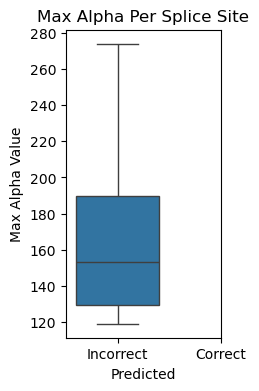

In [14]:
# Boxplot of max alpha values for correctly and incorrectly predicted splice sites
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(2, 4))
sns.boxplot(x='Correctly_Predicted', y='Alpha_max', data=results_df[results_df['True_class'] != BACKGROUND_CLASS])
plt.title("Max Alpha Per Splice Site")
plt.xlabel("Predicted")
plt.ylabel("Max Alpha Value")
#plt.yscale('log')
plt.xticks([0, 1], ['Incorrect', 'Correct'])
plt.show()

In [15]:
# How many true non-background positions?
n_trues = results_df["True_class"] != BACKGROUND_CLASS
n_false = results_df["True_class"] == BACKGROUND_CLASS
print(f"True positions: {n_trues.sum()}")
print(f"Background positions: {n_false.sum()}")

# How many are true positives (predicted non-background and true non-background)?
correct_non_bg = (results_df["Predicted_class"] == results_df["True_class"]) & (results_df["True_class"] != BACKGROUND_CLASS)
print(f"\nTrue positives: {correct_non_bg.sum()}")
for cls in range(4):
    cls_correct = (results_df["Predicted_class"] == cls) & (results_df["True_class"] == cls)
    print(f"  Class {cls} ({CLASS_LABELS[cls]}): {cls_correct.sum()} positions")

# How many are false negatives (predicted background but true non-background)?
false_negatives = (results_df["Predicted_class"] == BACKGROUND_CLASS) & (results_df["True_class"] != BACKGROUND_CLASS)
print(f"\nFalse negatives: {false_negatives.sum()}")
for cls in range(4):
    cls_fn = (results_df["Predicted_class"] == BACKGROUND_CLASS) & (results_df["True_class"] == cls)
    print(f"  Class {cls} ({CLASS_LABELS[cls]}): {cls_fn.sum()} positions")

# How many are misclassified (predicted non-background but true non-background, but predicted class is different from true class)?
misclassified = (results_df["Predicted_class"] != results_df["True_class"]) & (results_df["True_class"] != BACKGROUND_CLASS) & (results_df["Predicted_class"] != BACKGROUND_CLASS)
print(f"\nMisclassified: {misclassified.sum()}")
for cls in range(4):
    cls_mis = (results_df["Predicted_class"] == cls) & (results_df["True_class"] != cls) & (results_df["True_class"] != BACKGROUND_CLASS)
    print(f"  Class {cls} ({CLASS_LABELS[cls]}): {cls_mis.sum()} positions")

# How many are false positives (predicted non-background but true background)?
false_positives = (results_df["Predicted_class"] != BACKGROUND_CLASS) & (results_df["True_class"] == BACKGROUND_CLASS)
print(f"\nFalse positives: {false_positives.sum()}")
for cls in range(4):
    cls_fp = (results_df["Predicted_class"] == cls) & (results_df["True_class"] == BACKGROUND_CLASS)
    print(f"  Class {cls} ({CLASS_LABELS[cls]}): {cls_fp.sum()} positions")


True positions: 27
Background positions: 73

True positives: 27
  Class 0 (donor +): 8 positions
  Class 1 (acceptor +): 8 positions
  Class 2 (donor -): 5 positions
  Class 3 (acceptor -): 6 positions

False negatives: 0
  Class 0 (donor +): 0 positions
  Class 1 (acceptor +): 0 positions
  Class 2 (donor -): 0 positions
  Class 3 (acceptor -): 0 positions

Misclassified: 0
  Class 0 (donor +): 0 positions
  Class 1 (acceptor +): 0 positions
  Class 2 (donor -): 0 positions
  Class 3 (acceptor -): 0 positions

False positives: 73
  Class 0 (donor +): 3 positions
  Class 1 (acceptor +): 4 positions
  Class 2 (donor -): 34 positions
  Class 3 (acceptor -): 32 positions


In [16]:
# Summaize in a table
summary_df = pd.DataFrame({
    "Class": [CLASS_LABELS[cls] for cls in range(4)],
    "True positives": [((results_df["Predicted_class"] == cls) & (results_df["True_class"] == cls) & (results_df["True_class"] != BACKGROUND_CLASS)).sum() for cls in range(4)],
    "False negatives": [((results_df["Predicted_class"] == BACKGROUND_CLASS) & (results_df["True_class"] == cls)).sum() for cls in range(4)],
    "Misclassified": [((results_df["Predicted_class"] == cls) & (results_df["True_class"] != cls) & (results_df["True_class"] != BACKGROUND_CLASS)).sum() for cls in range(4)],
    "False positives": [((results_df["Predicted_class"] == cls) & (results_df["True_class"] == BACKGROUND_CLASS)).sum() for cls in range(4)],
})
summary_df

,Class,True positives,False negatives,Misclassified,False positives
0,donor +,8,0,0,3
1,acceptor +,8,0,0,4
2,donor -,5,0,0,34
3,acceptor -,6,0,0,32


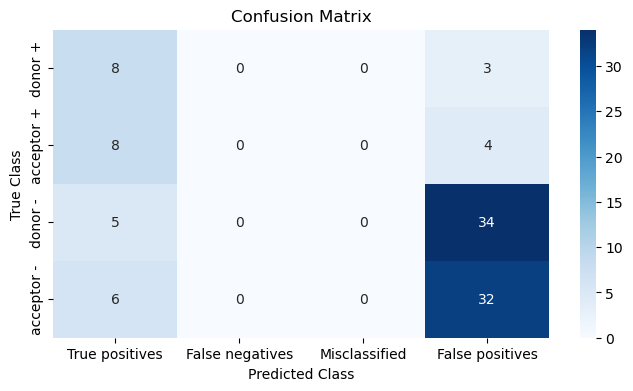

In [17]:
# Plot as heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.heatmap(summary_df.set_index("Class"), annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()